#   Inference - Gamma/Neutron

In [1]:
import pandas as pd
import numpy as np
from pynq import Overlay, allocate

Load overlay

In [2]:
# Load the FPGA hardware design (bitstream + metadata).
# The file "bd_wrapper_gn.xsa" was generated by Vivado and contains:
#   - The PL bitstream
#   - Hardware handoff information (address map, IP configuration)
#   - AXI interconnect descriptions used by PYNQ
#
# Loading the Overlay configures the programmable logic (PL) and
# exposes the hardware IP blocks as Python-accessible objects.
ol = Overlay("design_1_wrapper.xsa")


Explore available IP cores

In [3]:
# List all IP cores available in the loaded overlay.
# 'ip_dict' is a dictionary autogenerated by PYNQ, where:
#   - keys   = IP core names (as synthesized in Vivado)
#   - values = metadata (address ranges, driver info, registers, etc.)
#
# This is useful for discovering the names of DMA blocks,AXI-Lite peripherals, and custom accelerators.
list(ol.ip_dict.keys())

['axi_dma_0', 'myproject_auto_accel_0', 'zynq_ultra_ps_e_0']

Create objects

In [4]:
# Get a reference to the AXI DMA instance defined in the hardware design.
# The name 'axi_dma_0' must match the IP name inside the Vivado block design.
dma = ol.axi_dma_0

# DMA channels:
#   - sendchannel:  transfers data from PS → PL  (input to accelerator)
#   - recvchannel:  transfers data from PL → PS  (output from accelerator)
dma_send = dma.sendchannel
dma_recv = dma.recvchannel

# Get a reference to the custom accelerator IP core.
# 'myproject_gn_accel_0' is the name Vivado generated for the HLS module.
# This gives access to its AXI-Lite control registers (e.g., start, status).
ip = ol.myproject_auto_accel_0


Load testing dataset

Gamma/Neutron testing dataset is stored in a csv file. Normalization is requiered for this project.

In [24]:
import pandas as pd
import numpy as np
df = pd.read_csv("gn_test.csv", header=None)
df = df[df.iloc[:, -1] != "class"].reset_index(drop=True)

X      = df.iloc[:, :-1].astype(np.int32).to_numpy()
y_true = df.iloc[:, -1].astype(np.int32).to_numpy()

num_samples  = X.shape[0]
num_features = X.shape[1]
print(f"Samples: {num_samples}, Features: {num_features}")

Samples: 1798, Features: 161


In [26]:
# 3. Normalización PER-SAMPLE
#   x_norm = 2*(x - min) / (max - min) - 1   →  range [-1, 1]
X_min = X.min(axis=1, keepdims=True)   # shape (N, 1)
X_max = X.max(axis=1, keepdims=True)   # shape (N, 1)
rng   = np.where(X_max - X_min == 0, 1, X_max - X_min)  # avoid /0

X_norm = 2.0 * (X.astype(np.float32) - X_min) / rng - 1.0
X_norm = np.clip(X_norm, -1.0, 1.0)

print("X_norm range: [{:.4f}, {:.4f}]".format(X_norm.min(), X_norm.max()))


X_norm range: [-1.0000, 1.0000]


Define DMA buffers

In [27]:
# Conversion to ap_fixed<16,6> 
#   ap_fixed<16,6>: 1 sign + 5 int + 10 fractional
#   SCALE = 2^10 = 1024
SCALE   = 2**10
X_fixed = (np.clip(X_norm, -32.0, 31.999) * SCALE).astype(np.int16)

# DMA Buffers DMA 
NCLASSES   = 2
in_buffer  = allocate(shape=(num_features,), dtype=np.int32)
out_buffer = allocate(shape=(NCLASSES,),     dtype=np.int32)

Inference

In [28]:
y_pred = np.zeros(num_samples, dtype=np.int32)

for i in range(num_samples):
    # Copy the sample into the buffer (int16 → int32, value in the lower bits)
    in_buffer[:] = X_fixed[i].astype(np.int32)
    
    dma_recv = dma.recvchannel
    dma_send = dma.sendchannel
    
    dma_recv.transfer(out_buffer)
    ip.write(0x00, 1)              # AP_START
    dma_send.transfer(in_buffer)
    dma_send.wait()
    dma_recv.wait()
    
    # Decode ap_fixed<16,6> from the lower 16 bits of each word
    out0 = np.int16(out_buffer[0] & 0xFFFF).astype(np.float32) / SCALE
    out1 = np.int16(out_buffer[1] & 0xFFFF).astype(np.float32) / SCALE
    
    y_pred[i] = 0 if out0 >= out1 else 1

Confusion matrix

In [30]:
from utils import *

# Compute the confusion matrix for binary classification.
# `y_true` : ground-truth labels (0 = gamma, 1 = neutron)
# `y_pred` : predicted labels from the FPGA
# The last argument '2' specifies the number of classes.
cm = confusion_matrix_np(y_true, y_pred, 2)

# Display the confusion matrix in a human-readable format.
# Typically prints:
#   - True Negative (TN)
#   - False Positive (FP)
#   - False Negative (FN)
#   - True Positive (TP)
print_confusion_matrix(cm)


Confusion Matrix:
    Pred:     0     1
True  0:   899     0
True  1:     2   897


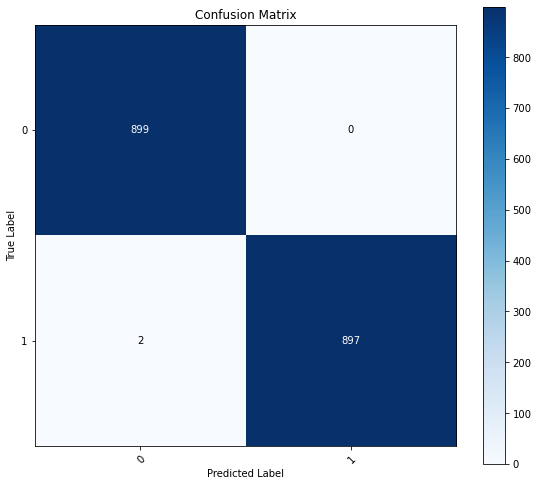

In [31]:
plot_confusion_matrix(cm, class_names=range(2))